In [5]:
# سلول 1: ایمپورت کتابخانه‌ها
import random
import numpy as np
from scipy.stats import norm
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo
import matplotlib.pyplot as plt
import json


In [6]:
# سلول 2: تنظیمات و توابع اصلی

TARGET_TIMEZONES = {
    "Tehran": "Asia/Tehran",
    "Baghdad": "Asia/Baghdad",
    "Riyadh": "Asia/Riyadh",
    "Jerusalem": "Asia/Jerusalem",
    "New York": "America/New_York",
    "Gaza": "Asia/Gaza",
}

SERVER_TIMEZONE = ZoneInfo("Asia/Tehran")

INTENSITY_LIMITS = {
    1: {"Like": (80, 130), "Comment": (30, 50), "Tweet": (20, 40),
        "Follow": (80, 130), "Retweet": (130, 180), "View": (300, 500), "quote": (10, 20)},
    2: {"Like": (140, 210), "Comment": (60, 90), "Tweet": (50, 90),
        "Follow": (140, 210), "Retweet": (140, 210), "View": (600, 800), "quote": (30, 40)},
    3: {"Like": (220, 290), "Comment": (100, 150), "Tweet": (120, 180),
        "Follow": (220, 290), "Retweet": (220, 290), "View": (900, 1100), "quote": (50, 70)}
}

ACTIVITIES = ["Like", "Comment", "Tweet", "Follow", "Retweet", "View", "quote"]

def generate_time_distribution(target_tz_str):
    utc_zone = ZoneInfo("UTC")
    target_zone = ZoneInfo(target_tz_str)
    base_date = datetime.now(tz=utc_zone).replace(hour=0, minute=0, second=0, microsecond=0)

    time_slots_target = []
    local_hours = []

    for minute_offset in range(24 * 60):
        utc_dt = base_date + timedelta(minutes=minute_offset)
        target_dt = utc_dt.astimezone(target_zone)

        time_slots_target.append(target_dt.strftime("%H:%M"))
        local_hours.append(target_dt.hour + target_dt.minute / 60)

    probabilities = np.zeros(len(time_slots_target))

    peak_a = norm(loc=21.5, scale=1.5)
    peak_b = norm(loc=12.5, scale=1.5)
    peak_c = norm(loc=9.0, scale=0.5)
    weight_a, weight_b, weight_c = 0.55, 0.35, 0.1

    for i, hour in enumerate(local_hours):
        prob = (weight_a * peak_a.pdf(hour) + weight_b * peak_b.pdf(hour) + weight_c * peak_c.pdf(hour))
        if 2 <= hour < 7:
            prob *= 0.1
        probabilities[i] = prob

    probabilities /= np.sum(probabilities)
    return time_slots_target, probabilities, local_hours

def select_times(n, time_slots, probabilities):
    if n == 0:
        return ["No action predicted"]
    return sorted(random.choices(time_slots, weights=probabilities, k=n))

def generate_daily_schedule(location, intensity_mode, **kwargs):
    tz_str = TARGET_TIMEZONES.get(location)
    if not tz_str:
        raise ValueError("Invalid location")

    time_slots, probabilities, local_hours = generate_time_distribution(tz_str)
    result = {}

    if intensity_mode == 4:
        for activity in ACTIVITIES:
            interval_str = kwargs.get(f"{activity.lower()}_interval")
            try:
                count = int(interval_str)
            except (ValueError, TypeError):
                count = 0

            times = select_times(count, time_slots, probabilities) if count > 0 else ["No action predicted"]
            result[activity] = {"count": count, "times": times}
    else:
        limits = INTENSITY_LIMITS[intensity_mode]
        for activity in ACTIVITIES:
            low, high = limits[activity]
            count = random.randint(low, high)
            times = select_times(count, time_slots, probabilities)
            result[activity] = {"count": count, "times": times}

    return result, time_slots, probabilities, local_hours


In [7]:
# Cell 3: Visualization function with separate histograms per activity

def plot_distribution(local_hours, probabilities, schedule):
    plt.figure(figsize=(12, 5))

    # Plot overall activity probability distribution
    plt.bar(local_hours, probabilities, width=0.02, color='skyblue')
    plt.xlabel("Local Hour (decimal hours)")
    plt.ylabel("Activity Probability")
    plt.title("Daily Activity Probability Distribution")
    plt.tight_layout()
    plt.show()

    bins = np.linspace(0, 24, 49)  # half-hour bins

    # Plot separate histogram for each activity
    for activity in ACTIVITIES:
        times = schedule[activity]["times"]
        if "No action predicted" in times:
            print(f"{activity}: No actions predicted.")
            continue

        hours = []
        for t in times:
            h, m = map(int, t.split(":"))
            hours.append(h + m / 60)

        plt.figure(figsize=(10, 3))
        plt.hist(hours, bins=bins, alpha=0.7, color='orange', edgecolor='black', density=True)
        plt.xlabel("Local Hour")
        plt.ylabel("Density")
        plt.title(f"Time Distribution for {activity}")
        plt.grid(True)
        plt.show()


{
    "Like": {
        "count": 86,
        "times": [
            "08:18",
            "08:24",
            "08:26",
            "09:06",
            "09:06",
            "09:07",
            "09:12",
            "09:24",
            "09:31",
            "09:59",
            "10:04",
            "10:18",
            "10:24",
            "10:37",
            "11:07",
            "11:33",
            "11:34",
            "11:44",
            "12:01",
            "12:01",
            "12:12",
            "12:19",
            "12:24",
            "12:32",
            "12:33",
            "12:33",
            "12:40",
            "12:42",
            "12:43",
            "12:45",
            "12:46",
            "12:55",
            "13:07",
            "13:15",
            "13:19",
            "13:22",
            "13:29",
            "13:36",
            "13:45",
            "13:56",
            "14:23",
            "14:25",
            "14:27",
            "14:44",
            "15:17",

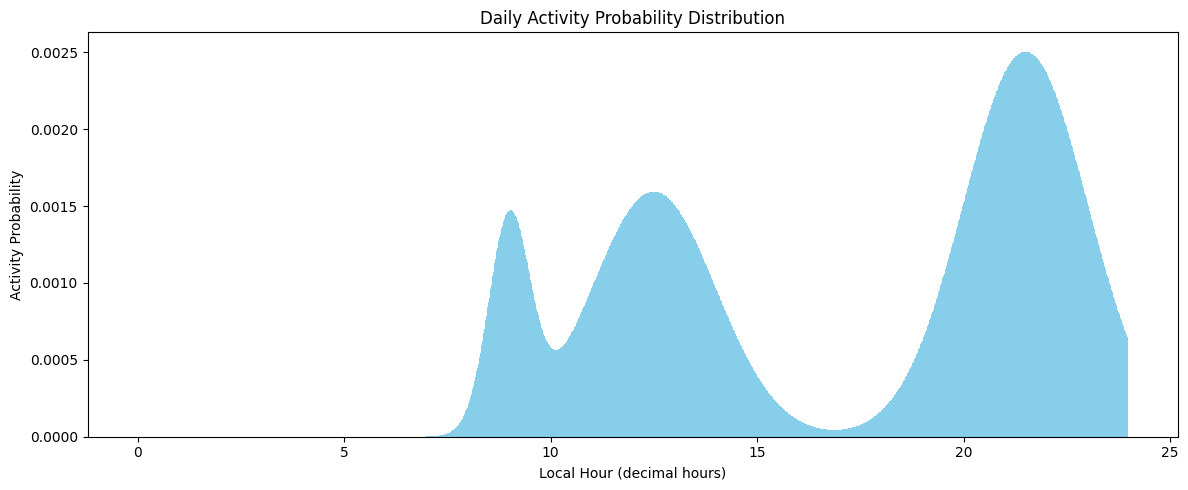

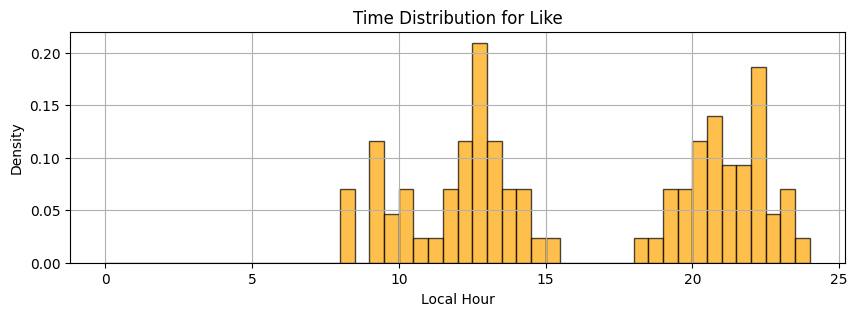

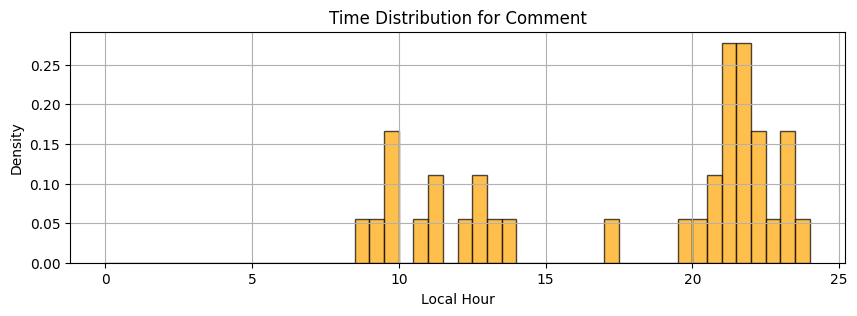

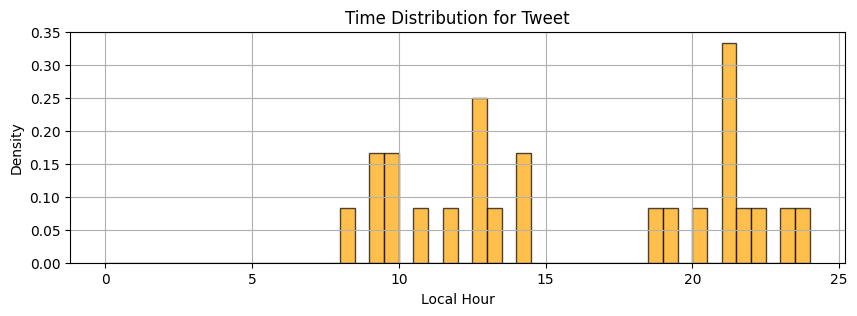

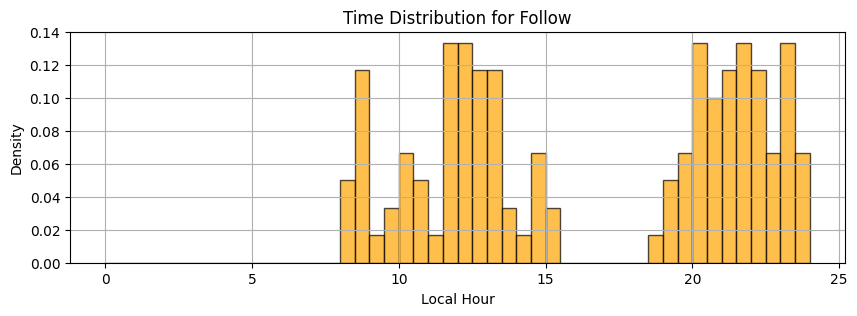

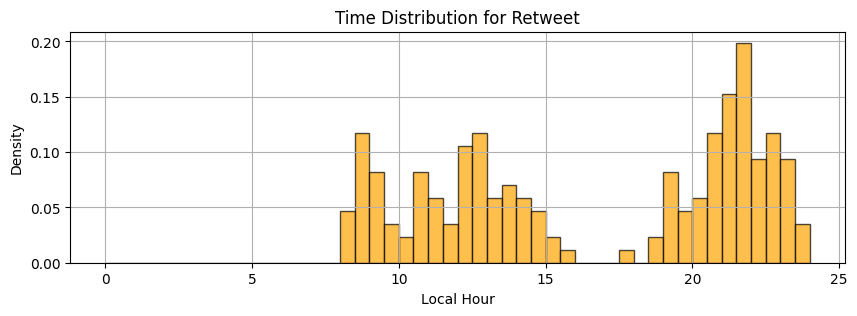

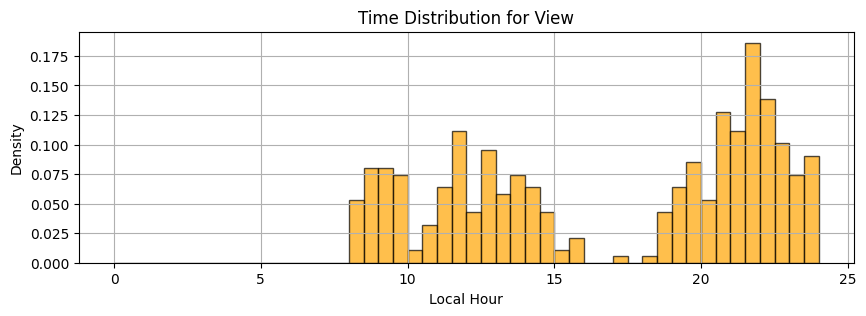

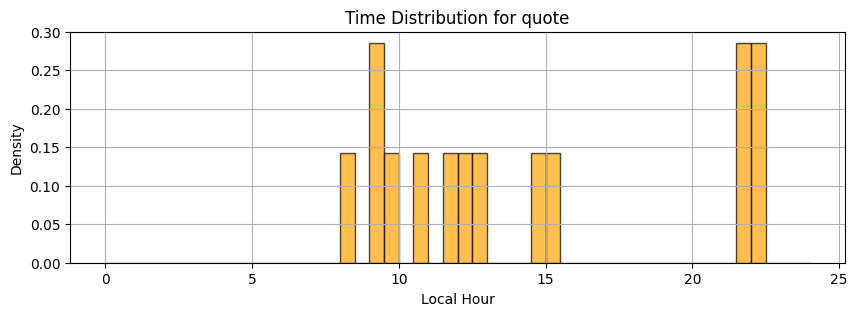

In [15]:
# Cell 4: Run example and visualize

location = "New York"     # Change to desired location
intensity_mode = 1      # 1, 2, 3 or 4

kwargs = {
    "like_interval": "5",
    "comment_interval": "0",
    "tweet_interval": "3",
    "follow_interval": "0",
    "retweet_interval": "2",
    "view_interval": "0",
    "quote_interval": "1",
}

schedule, time_slots, probabilities, local_hours = generate_daily_schedule(location, intensity_mode, **kwargs)

print(json.dumps(schedule, indent=4))

plot_distribution(local_hours, probabilities, schedule)


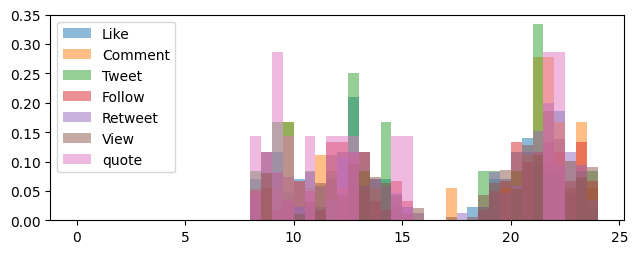

In [16]:
    # رسم هیستوگرام توزیع ساعت‌ها برای هر فعالیت
    plt.subplot(2, 1, 2)
    bins = np.linspace(0, 24, 49)  # تقسیم به هر نیم ساعت

    for activity in ACTIVITIES:
        times = schedule[activity]["times"]
        if "No action predicted" in times:
            continue
        # تبدیل ساعت‌های رشته‌ای به عدد ساعت (کسر دقیقه)
        hours = []
        for t in times:
            h, m = map(int, t.split(":"))
            hours.append(h + m / 60)

        plt.hist(hours, bins=bins, alpha=0.5, label=activity, density=True)

    plt.legend()
    plt.tight_layout()
    plt.show()

